In [104]:
from pathlib import Path

from clearml import Dataset
import pandas as pd
from tqdm.notebook import tqdm
from plotly import express as px
import matplotlib.pyplot as plt

In [105]:
data_root = Dataset.get(
    dataset_project="ForeSightNEXT/Electric Load Forecasting",
    dataset_name="household-1235",
    dataset_version="2.0.0",
).get_local_copy()

In [106]:
combined = pd.read_csv(
    "../data/combined.csv",
        index_col="_time",
        parse_dates=True,
        date_format="ISO8601"
    )
combined.index = pd.to_datetime(combined.index, utc=True)
combined.head(3)

,Smart Switch 6 Spülmaschine,DECT200 Spülmaschine
_time,,
2020-08-04 05:43:02.535000+00:00,NaN,0.68
2020-08-04 05:43:11.528000+00:00,NaN,0.68
2020-08-04 05:43:21.541000+00:00,NaN,0.68


In [109]:
new_df = combined[['Smart Switch 6 Spülmaschine']].dropna()

In [110]:
def time_delta_stats(df, ts_col='_time', use_index=True, drop_duplicates=False):
    """
    Returns min, max, median, mean time deltas between consecutive timestamps.
    - ts_col: name of the datetime column (ignored if use_index=True)
    - use_index: set True if your index is already a DatetimeIndex
    - drop_duplicates: drop identical timestamps before computing diffs
    """
    # 1) get a sorted datetime Series
    if use_index:
        s = pd.Series(df.index)
        if not isinstance(df.index, pd.DatetimeIndex):
            s = pd.to_datetime(s, utc=True, errors='coerce')
    else:
        s = pd.to_datetime(df[ts_col], utc=True, errors='coerce')
    s = s.dropna().sort_values()

    if drop_duplicates:
        s = s[~s.duplicated(keep='first')]

    # 2) consecutive diffs
    d = s.diff().dropna()                   # dtype: timedelta64[ns]

    # 3) stats as timedeltas
    stats_td = d.agg(['min', 'max', 'median', 'mean'])

    # 4) same stats in seconds (handy for reporting)
    stats_sec = stats_td / pd.Timedelta(seconds=1)
    stats_sec.index = [f'{k}_sec' for k in stats_sec.index]

    # 5) combine
    out = pd.concat([stats_td, stats_sec])
    return out

def interpolate_small_gaps_df(df, ts_col, y_col, freq, threshold, method='time'):
    """
    Interpolate only across gaps <= `threshold`.
    - ts_col: name of datetime column
    - y_col: value column to interpolate
    - freq: target grid frequency, e.g. '1min', '15min'
    - threshold: e.g. '30min', '2H' (anything pandas.Timedelta understands)
    - method: 'time' (for DatetimeIndex), or 'linear', etc.
    """
    td = pd.Timedelta(threshold)

    s = (df.assign(**{ts_col: pd.to_datetime(df[ts_col])})
           .set_index(ts_col)
           .sort_index()[y_col])

    # 1) regular grid
    s = s.asfreq(freq)

    # 2) endpoints of each NaN run
    prev_valid_time = s.index.to_series().where(s.notna()).ffill()
    next_valid_time = s.index.to_series().where(s.notna()).bfill()
    span = next_valid_time - prev_valid_time               # timedelta across the gap

    # 3) interpolate, then keep only fills where span <= threshold
    filled = s.interpolate(method=method, limit_area='inside')
    keep = (span <= td) | s.notna()                        # always keep original points
    result = filled.where(keep)

    return result

# Example:
# out = interpolate_small_gaps(df, ts_col='timestamp', y_col='value',
#                              freq='5min', threshold='30min')

def interpolate_small_gaps_series(s, freq, threshold, method='time'):
    """
    s: pandas Series with a DatetimeIndex (may be irregular)
    Only interpolates gaps whose total span <= threshold.
    """
    td = pd.Timedelta(threshold)
    s = s.copy()

    # ensure datetime index and handle duplicate timestamps
    if not isinstance(s.index, pd.DatetimeIndex):
        s.index = pd.to_datetime(s.index, format='ISO8601')
    s = s.sort_index()
    if not s.index.is_unique:
        s = s.groupby(level=0).mean()   # or .last(), .sum(), as appropriate

    # put on regular grid
    s = s.asfreq(freq)

    print(s)

    # gap span across each NaN run
    prev_valid_time = s.index.to_series().where(s.notna()).ffill()
    next_valid_time = s.index.to_series().where(s.notna()).bfill()
    span = next_valid_time - prev_valid_time

    # interpolate only small gaps
    filled = s.interpolate(method=method, limit_area='inside')
    return filled.where((span <= td) | s.notna())

In [ ]:
# df has columns: timestamp, energy_Wh  (each row is an amount, not a meter reading)
df = new_df.copy()
# df['_time'] = pd.to_datetime(df['_time'], utc=True, errors='coerce')
# df = df.resample('10s').mean()
df.to_csv('before_before.csv')
s = (df.groupby('_time', as_index=True)['Smart Switch 6 Spülmaschine']      # combine duplicate timestamps, if any
       .sum()
       .sort_index()
       .cumsum())                                             # cumulative energy

d = s.index.to_series().diff().dropna()
print(pd.Series({
    'min': d.min(), 'max': d.max(), 'median': d.median(), 'mean': d.mean()
}))

s_sampled = s.resample('10s', label='right', closed='right').last().ffill()

# print(s_sampled)

# s.index = pd.to_datetime(s.index, format='ISO8601', utc=True)
# if not isinstance(s.index, pd.DatetimeIndex):
#     s.index = pd.to_datetime(s.index, utc=True)
# s = s.sort_index()
# s.to_csv('test_before.csv')

# # s['timestamp'] = pd.to_datetime(s.index, utc=True, format='ISO8601')
# s_sampled = s.resample('10s', label='right', closed='right').last()
print(s_sampled)
s_sampled.to_csv('test_interpolation.csv')
# interpolated_s = interpolate_small_gaps_series(s_sampled, freq='10s', threshold="10h")
# print(interpolated_s)


# # put on a regular grid, e.g. 15 minutes
# idx = pd.date_range(s.index.min().floor('15min'),
#                     s.index.max().ceil('15min'),
#                     freq='15min', tz=s.index.tz)
# cum_Wh = s.reindex(idx).ffill().fillna(0)    

# fig = px.scatter(s_sampled[:2000])
fig = px.scatter(s[:200])
fig.update_layout(height=400)
fig.update_layout(width=800)
fig.update_layout(legend=dict(
    title=None,
    orientation="h",
    yanchor="bottom",
    y=1.02,
    xanchor="right",
    x=1
))
fig.show()

min      0 days 00:00:10
max      0 days 00:00:10
median   0 days 00:00:10
mean     0 days 00:00:10
dtype: timedelta64[ns]
_time
2021-03-24 10:27:40+00:00    0.000000e+00
2021-03-24 10:27:50+00:00    0.000000e+00
2021-03-24 10:28:00+00:00    0.000000e+00
2021-03-24 10:28:10+00:00    0.000000e+00
2021-03-24 10:28:20+00:00    0.000000e+00
                                 ...     
2022-06-13 06:02:50+00:00    3.165744e+06
2022-06-13 06:03:00+00:00    3.165744e+06
2022-06-13 06:03:10+00:00    3.165744e+06
2022-06-13 06:03:20+00:00    3.165744e+06
2022-06-13 06:03:30+00:00    3.165744e+06
Freq: 10s, Name: Smart Switch 6 Spülmaschine, Length: 3851856, dtype: float64


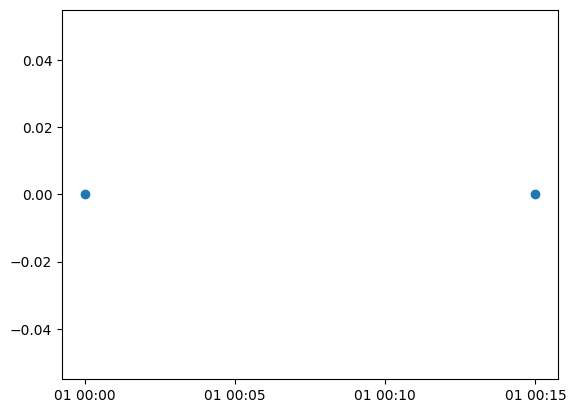

In [42]:
plot_df = new[5000:11000]
plt.scatter(cum_Wh.index, cum_Wh)

In [32]:
plot_interval = new[4000:6000]
fig = px.scatter(plot_interval)
fig.update_layout(height=400)
fig.update_layout(width=800)
fig.update_layout(legend=dict(
    title=None,
    orientation="h",
    yanchor="bottom",
    y=1.02,
    xanchor="right",
    x=1
))
fig.show()